In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [1]:
## Dataset contain total 1295 images of 3 classes. the dataset is imbalanced with the 3 classes having 500,400,395 images respectively.


In [2]:
import tensorflow_datasets as tfds

# Load dataset
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    'beans',
    split=['train', 'validation', 'test'],
    shuffle_files=True,
    as_supervised=True,  # returns (image, label) pairs
    with_info=True
)

print(ds_info)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.M0UY7E_0.1.0/beans-train.tfrecord*...:   0%|          | 0…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.M0UY7E_0.1.0/beans-validation.tfrecord*...:   0%|        …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/beans/incomplete.M0UY7E_0.1.0/beans-test.tfrecord*...:   0%|          | 0/…

Dataset beans downloaded and prepared to /root/tensorflow_datasets/beans/0.1.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='beans',
    full_name='beans/0.1.0',
    description="""
    Beans is a dataset of images of beans taken in the field using smartphone
    cameras. It consists of 3 classes: 2 disease classes and the healthy class.
    Diseases depicted include Angular Leaf Spot and Bean Rust. Data was annotated by
    experts from the National Crops Resources Research Institute (NaCRRI) in Uganda
    and collected by the Makerere AI research lab.
    """,
    homepage='https://github.com/AI-Lab-Makerere/ibean/',
    data_dir='/root/tensorflow_datasets/beans/0.1.0',
    file_format=tfrecord,
    download_size=171.69 MiB,
    dataset_size=171.63 MiB,
    features=FeaturesDict({
        'image': Image(shape=(500, 500, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    di

In [ ]:
label_name=ds_info.features['label'].names
print(label_name)

['angular_leaf_spot', 'bean_rust', 'healthy']


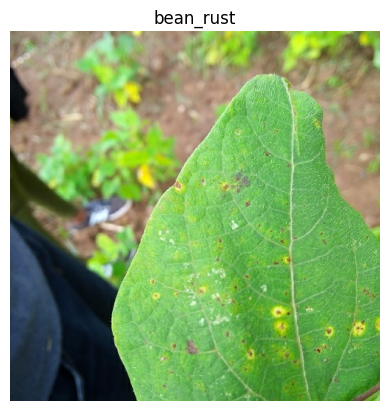

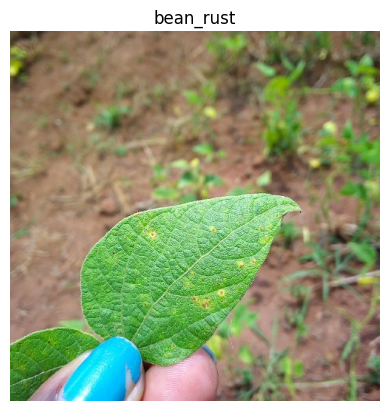

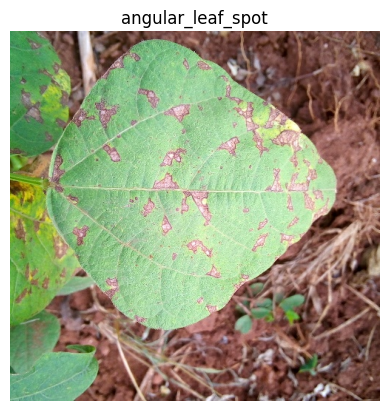

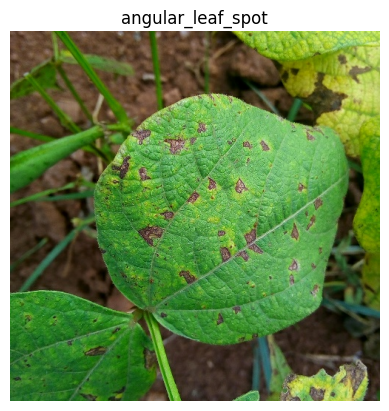

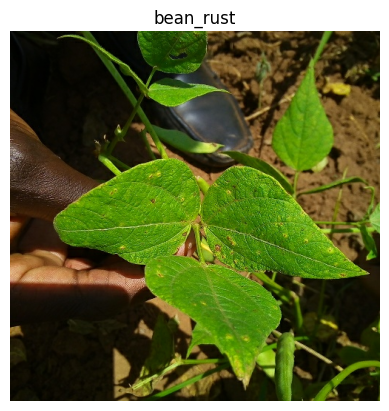

In [4]:
for image,label in ds_train.take(5):
    plt.imshow(image)
    plt.title(label_name[label])
    plt.axis('off')
    plt.show()

In [ ]:
IMG_SIZE = 224

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)   # DO NOT divide by 255 for MobileNet
    return image, label

train_ds = ds_train.map(preprocess)
val_ds = ds_val.map(preprocess).batch(32)
test_ds = ds_test.map(preprocess).batch(32)

train_ds = train_ds.shuffle(1000).batch(32)

# Prefetch for performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)    ## Prefetching allows the data pipeline to prepare the next batch of data while the current batch is being processed by the model, improving performance.
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
## Data Balancing with Class Weights

class_weights = {
    0: 1.0,   # angular_leaf_spot
    1: 1.0,   # bean_rust
    2: 3.0    # healthy (boost minority class)
}

In [ ]:
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
NUM_CLASSES = 3

base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights="imagenet"  ## Using pre trained weights from ImageNET.
)

base_model.trainable = False  # PHASE 1: freeze backbone

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)   # apply augmentation
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)   ## Taking Average of the feature maps to get a single value per feature map.
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


print("\n TRAINING PHASE 1 (Training top classifier only)")

history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)


 TRAINING PHASE 1 (Training top classifier only)
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.4005 - loss: 1.8883 - val_accuracy: 0.6015 - val_loss: 0.8301
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7067 - loss: 0.7495 - val_accuracy: 0.6842 - val_loss: 0.7021
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.8143 - loss: 0.5739 - val_accuracy: 0.8195 - val_loss: 0.4918
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8431 - loss: 0.4993 - val_accuracy: 0.8195 - val_loss: 0.4506
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.8375 - loss: 0.4804 - val_accuracy: 0.7820 - val_loss: 0.4914
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8454 - loss: 0.4904 - val_accuracy: 0.8421 - val_loss: 0.3984
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8600 - loss: 0.4268 - val_accuracy: 0.8496 - val_loss: 0.3673
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8543

In [15]:
print("\n TRAINING PHASE 2 (Fine-tuning last 40 layers)")

base_model.trainable = True

# Unfreeze only last 40 layers
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # VERY IMPORTANT (low LR)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights
)


 TRAINING PHASE 2 (Fine-tuning last 40 layers)
Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.3643 - loss: 2.0215 - val_accuracy: 0.4812 - val_loss: 1.0006
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.5843 - loss: 1.2769 - val_accuracy: 0.5564 - val_loss: 0.8759
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.6115 - loss: 1.0048 - val_accuracy: 0.6165 - val_loss: 0.7846
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.7334 - loss: 0.7481 - val_accuracy: 0.6767 - val_loss: 0.7102
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.7585 - loss: 0.7112 - val_accuracy: 0.7143 - val_loss: 0.6616
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.8066 - loss: 0.5915 - val_accuracy: 0.7444 - val_loss: 0.6312
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.8069 - loss: 0.5228 - val_accuracy: 0.7519 - val_loss: 0.6051
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.

In [ ]:
#  ------------------ MODEL EVALUATION ------------------
test_loss, test_acc = model.evaluate(test_ds)
print("\n TEST ACCURACY:", test_acc)


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8802 - loss: 0.3840

 TEST ACCURACY: 0.890625


In [18]:
label_names=ds_info.features['label'].names
print(label_name)


['angular_leaf_spot', 'bean_rust', 'healthy']


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


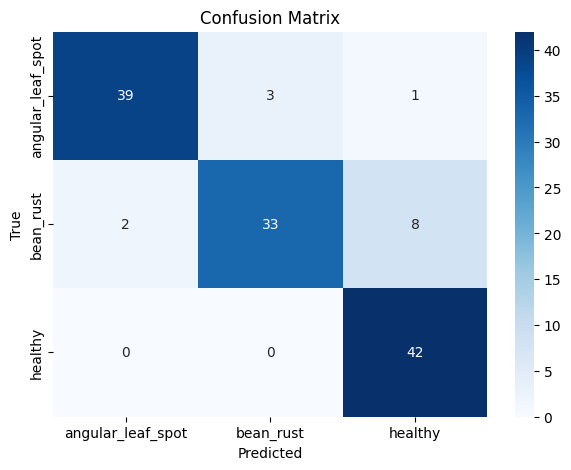

In [ ]:

#  ------------------ CONFUSION MATRIX ------------------
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_names,
            yticklabels=label_names,
            cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [20]:

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_names))



Classification Report:

                   precision    recall  f1-score   support

angular_leaf_spot       0.95      0.91      0.93        43
        bean_rust       0.92      0.77      0.84        43
          healthy       0.82      1.00      0.90        42

         accuracy                           0.89       128
        macro avg       0.90      0.89      0.89       128
     weighted avg       0.90      0.89      0.89       128



In [ ]:

#  ------------------ INFERENCE ON UNKNOWN IMAGE ------------------
from tensorflow.keras.preprocessing import image

def predict_unknown(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    img_array = keras.applications.mobilenet_v2.preprocess_input(img_array)

    preds = model.predict(img_array)[0]
    class_idx = np.argmax(preds)

    print("Predicted:", label_names[class_idx])
    print("Confidence:", preds[class_idx])



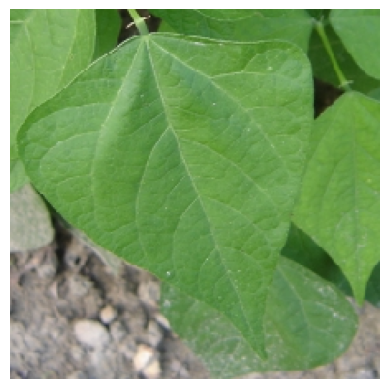

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted: healthy
Confidence: 0.58238274


In [29]:

predict_unknown("/content/Screenshot_27-2-2026_17657_www.bing.com.jpeg")